In [11]:
# PHYS 311
# LAB 5 - ORBITAL MECHANICS SIMULATOR
# Alexander Berry
# September 22, 2026

# IMPORT TOOLS

import numpy as np
import matplotlib.pyplot as plt

# SIMULATION CONSTANTS

G = 1.0
M = 1.0 
m = 1.0

## Part A - Single Orbit with Velocity Verlet

In this part, we model the motion of a planet orbiting a fixed central star using Newton's law of universal gravitation as well as the Velocity Verlet integration method.

Furthermore, we define the gravitational acceleration and implement the Velocity integrator. We then plot the orbital trajectory and track the total mechanical energy and the angular momentum vs. time, and evaluate the accuracy/stability of the simulation.

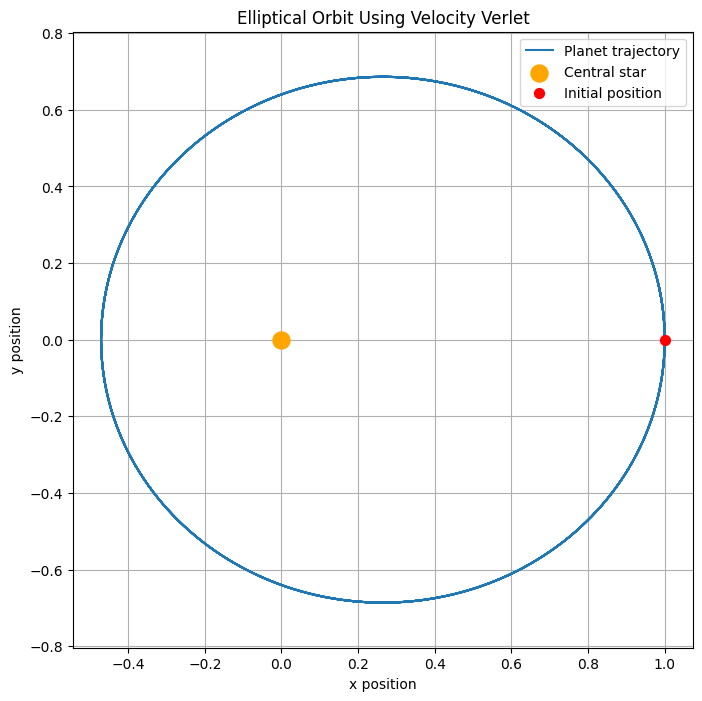

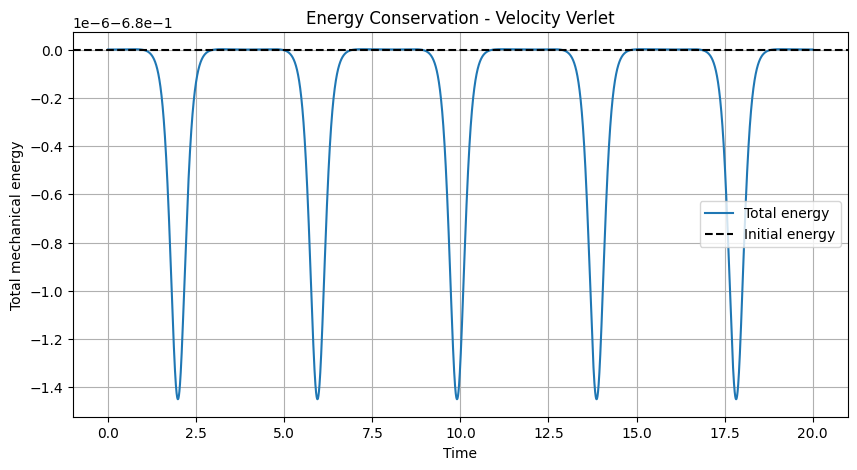

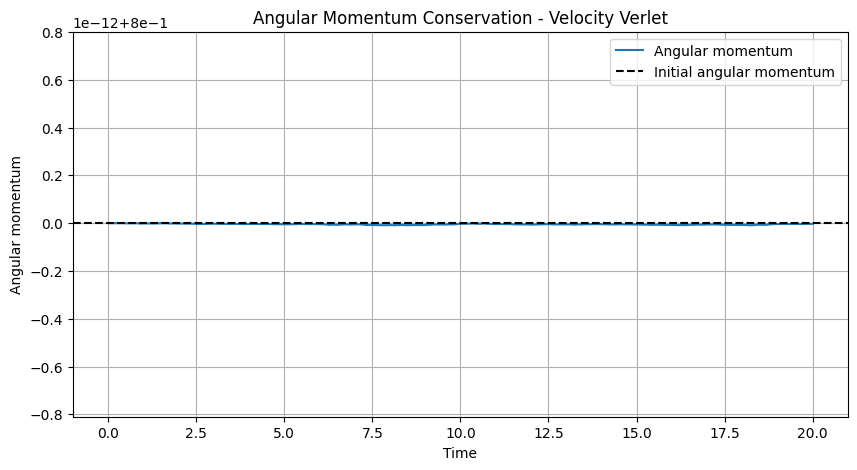

PART A - CONSERVATION RESULTS
-------------------------------------------------------
Initial energy: -0.68000000
Final energy:   -0.68000000
Maximum fractional energy error: 2.131864e-06

Initial angular momentum: 0.80000000
Final angular momentum:   0.80000000
Maximum fractional angular momentum error: 1.179612e-14

Initial acceleration: [-1. -0.]
Circular speed at r = 1: 1.0000


In [12]:
# PART A - A SINGLE ORBIT WITH VELOCITY VERLET

# A1. GRAVITATIONAL ACCELERATION FUNCTION

def accel(r):
    """Calculate gravitational acceleration toward the central star."""

    dist = np.linalg.norm(r)

    return -G * M * r / dist**3

# A2. VELOCITY VERLET INTEGRATOR

def verlet_step(r, v, a, dt, accel_func):
    """Perform one Velocity Verlet integration step."""

    # Update position
    r_new = r + v * dt + 0.5 * a * dt**2

    # Calculate acceleration at the new position
    a_new = accel_func(r_new)

    # Update velocity
    v_new = v + 0.5 * (a + a_new) * dt

    return r_new, v_new, a_new

# A3. ENERGY AND ANGULAR MOMENTUM FUNCTIONS

def energy(r, v, G=1.0, M=1.0, m=1.0):
    """Calculate total mechanical energy."""

    ke = 0.5 * m * np.dot(v, v)

    pe = -G * M * m / np.linalg.norm(r)

    return ke + pe

def ang_momentum(r, v, m=1.0):
    """Calculate angular momentum in two dimensions."""

    return m * (r[0] * v[1] - r[1] * v[0])

# A4. INITIAL CONDITIONS

r0 = np.array([1.0, 0.0])
v0 = np.array([0.0, 0.8])

r = r0.copy()
v = v0.copy()
a = accel(r)

dt = 0.001
n_steps = 20000

# Store the initial conditions
rs = [r.copy()]
vs = [v.copy()]

energies = [energy(r, v)]
angular_momenta = [ang_momentum(r, v)]

# A5. ORBITAL SIMULATION

for _ in range(n_steps):

    # Advance the simulation by one step
    r, v, a = verlet_step(r, v, a, dt, accel)

    # Store position and velocity
    rs.append(r.copy())
    vs.append(v.copy())

    # Track conserved quantities
    energies.append(energy(r, v))
    angular_momenta.append(ang_momentum(r, v))

# Convert lists into NumPy arrays
rs = np.array(rs)
vs = np.array(vs)

energies = np.array(energies)
angular_momenta = np.array(angular_momenta)

times = np.arange(n_steps + 1) * dt

# A6. ORBITAL TRAJECTORY

plt.figure(figsize=(8, 8))

plt.plot(
    rs[:, 0],
    rs[:, 1],
    label="Planet trajectory"
)

plt.scatter(
    0, 0,
    color="orange",
    s=150,
    label="Central star",
    zorder=5
)

plt.scatter(
    r0[0],
    r0[1],
    color="red",
    s=50,
    label="Initial position",
    zorder=5
)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Elliptical Orbit Using Velocity Verlet")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# A7. ENERGY CONSERVATION

plt.figure(figsize=(10, 5))

plt.plot(times, energies, label="Total energy")

plt.axhline(
    energies[0],
    color="black",
    linestyle="--",
    label="Initial energy"
)

plt.xlabel("Time")
plt.ylabel("Total mechanical energy")
plt.title("Energy Conservation - Velocity Verlet")

plt.grid(True)
plt.legend()
plt.show()

# A8. ANGULAR MOMENTUM CONSERVATION

plt.figure(figsize=(10, 5))

plt.plot(
    times,
    angular_momenta,
    label="Angular momentum"
)

plt.axhline(
    angular_momenta[0],
    color="black",
    linestyle="--",
    label="Initial angular momentum"
)

plt.xlabel("Time")
plt.ylabel("Angular momentum")
plt.title("Angular Momentum Conservation - Velocity Verlet")

plt.grid(True)
plt.legend()
plt.show()

# A9. CONSERVATION ERROR ANALYSIS

energy_error = np.abs(
    (energies - energies[0]) / energies[0]
)

angular_momentum_error = np.abs(
    (angular_momenta - angular_momenta[0])
    / angular_momenta[0]
)

print("PART A - CONSERVATION RESULTS")
print("-" * 55)

print(f"Initial energy: {energies[0]:.8f}")
print(f"Final energy:   {energies[-1]:.8f}")

print(
    f"Maximum fractional energy error: "
    f"{np.max(energy_error):.6e}"
)

print()

print(
    f"Initial angular momentum: "
    f"{angular_momenta[0]:.8f}"
)

print(
    f"Final angular momentum:   "
    f"{angular_momenta[-1]:.8f}"
)

print(
    f"Maximum fractional angular momentum error: "
    f"{np.max(angular_momentum_error):.6e}"
)

print()

print(f"Initial acceleration: {accel(r0)}")
print(f"Circular speed at r = 1: {np.sqrt(G * M):.4f}")

## Part A - Intrepretation

The initial position of the planet is apoaspsis (the point furthest from the central star). With an initial radius of 1.0, the circular orbital speed is set to 1.0. Given that the planet begins with a tangential velocity of 0.8, it moves too slowly to maintain a circular orbit, and as a result, begins moving inward toward the star.

The orbital trajectory from the simulation demonstrates the expected elliptical motion, with the central star resting at one focus of said ellipse. The planet itself completes multiple orbits while still maintaining an approximately closed trajectory, without any spiraling.

The inital total mechanical energy was -0.68000000, the final ernergy was also found to be -0.68000000. However, the maximum fractional energy error still produced 2.131864e-06, which corresponds to approximately 0.000213% of the systems total mechanical energy. Furthermore, the energy in the graph shows relatively small periodic fluctionations rather than a continous increase or decrease. This demonstrates that the Velocity Verlet maintains a stable orbit across the entire simulation.

To that end, the initial and final angular momentum remained approximately constant throughout the simulation, resting at 0.80000000. The maximum fractional angular momentum error was found to be 1.17962e-14, which indicates that the angular momentum was conserved within floating-point precision.

Overall, the results help demonstrate how Velocity Verlet successfully reproduces a stable elliptical orbit whilst maintaing both energy and angular momentum (to a very high degree of accuracy).Though the method does not conserve the "exact" mechanical energy at each time step, the bounded fluctations prevent any long-term numerical drifts.

## Part B - The Integrator Showdown

In this part, we compare three numerical integration techniques with one another: Euler, Euler-Cromer, and Velocity Verlet.

Utilizing the same initial conditions, gravitational acceleration function, time step, and simulation duration, we are able to simulate a planet's orbit for each method used. This ultimately allows us to isolate the effects of numerical integration onto the stability of orbit and the system's energy conservation.

We then generate plots and compare the collected data for each method, in order to evaluate their individual accuracies.

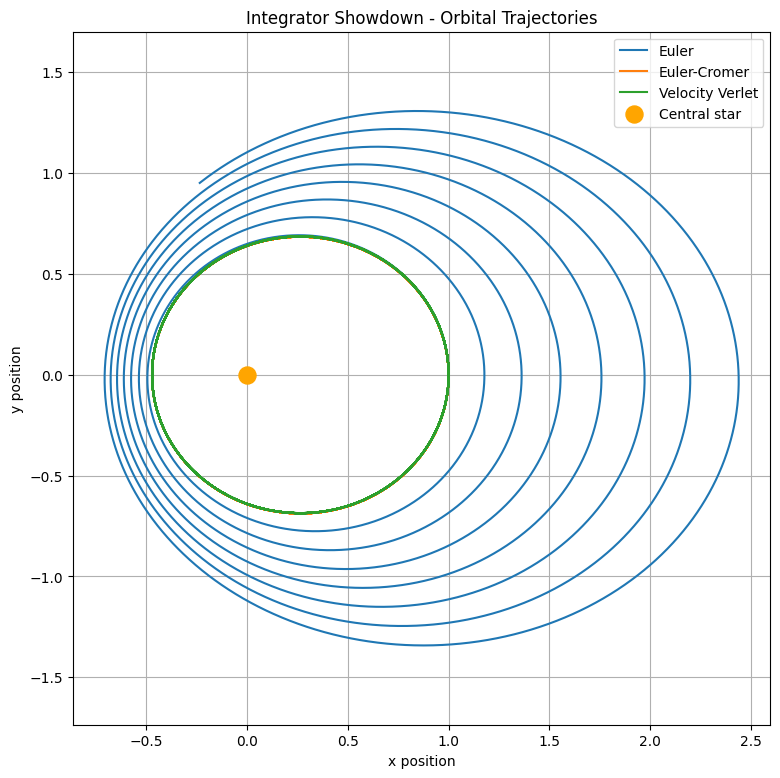

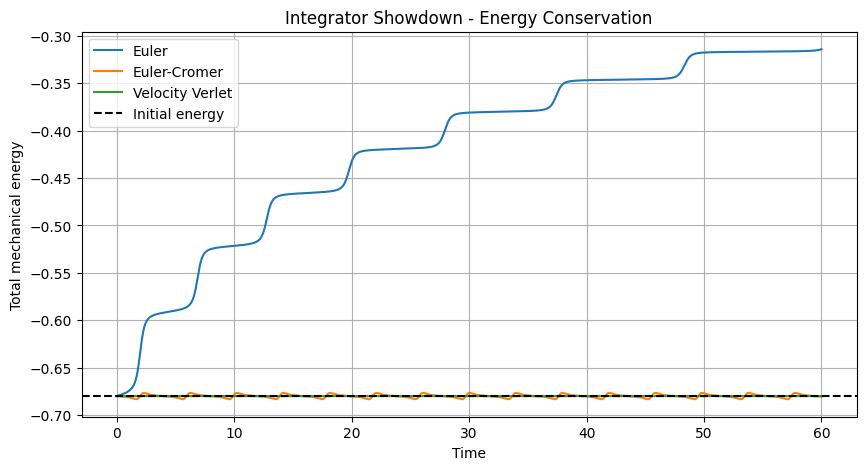

INTEGRATOR ENERGY ERROR SUMMARY
-------------------------------------------------------
Method               |  Maximum fractional error
-------------------------------------------------------
Euler                |              5.381464e-01
Euler-Cromer         |              4.913010e-03
Velocity Verlet      |              5.328643e-05
-------------------------------------------------------


In [13]:

# PART B - THE INTEGRATOR SHOWDOWN

# B1. UNIFIED SIMULATION FUNCTION

def simulate(method, dt, n_steps):
    """
    Simulate an orbit using Euler, Euler-Cromer,
    or Velocity Verlet.
    """

    # Initial conditions
    r = r0.copy()
    v = v0.copy()
    a = accel(r)

    # Storage
    positions = [r.copy()]
    velocities = [v.copy()]
    total_energies = [energy(r, v)]

    # Main simulation loop
    for _ in range(n_steps):

        if method == "euler":

            # Update position using current velocity
            r_new = r + v * dt

            # Update velocity using current acceleration
            v_new = v + a * dt

            # Calculate acceleration at new position
            a_new = accel(r_new)

        elif method == "euler-cromer":

            # Update velocity first
            v_new = v + a * dt

            # Update position using new velocity
            r_new = r + v_new * dt

            # Calculate acceleration at new position
            a_new = accel(r_new)

        elif method == "verlet":

            # Perform one Velocity Verlet step
            r_new, v_new, a_new = verlet_step(
                r, v, a, dt, accel
            )

        else:

            raise ValueError("Unknown integration method.")

        # Update state
        r = r_new
        v = v_new
        a = a_new

        # Store results
        positions.append(r.copy())
        velocities.append(v.copy())
        total_energies.append(energy(r, v))

    return (
        np.array(positions),
        np.array(velocities),
        np.array(total_energies)
    )

# B2. SIMULATION PARAMETERS

dt_B = 0.005
n_steps_B = 12000

times_B = np.arange(n_steps_B + 1) * dt_B

# B3. RUN ALL THREE INTEGRATORS

rs_euler, vs_euler, E_euler = simulate(
    "euler", dt_B, n_steps_B
)

rs_cromer, vs_cromer, E_cromer = simulate(
    "euler-cromer", dt_B, n_steps_B
)

rs_verlet, vs_verlet, E_verlet = simulate(
    "verlet", dt_B, n_steps_B
)

# B4. ORBITAL TRAJECTORY COMPARISON

plt.figure(figsize=(9, 9))

plt.plot(
    rs_euler[:, 0],
    rs_euler[:, 1],
    label="Euler"
)

plt.plot(
    rs_cromer[:, 0],
    rs_cromer[:, 1],
    label="Euler-Cromer"
)

plt.plot(
    rs_verlet[:, 0],
    rs_verlet[:, 1],
    label="Velocity Verlet"
)

# Mark the central star
plt.scatter(
    0, 0,
    color="orange",
    s=150,
    label="Central star",
    zorder=5
)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Integrator Showdown - Orbital Trajectories")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# B5. ENERGY CONSERVATION COMPARISON

plt.figure(figsize=(10, 5))

plt.plot(
    times_B,
    E_euler,
    label="Euler"
)

plt.plot(
    times_B,
    E_cromer,
    label="Euler-Cromer"
)

plt.plot(
    times_B,
    E_verlet,
    label="Velocity Verlet"
)

# Initial energy reference
plt.axhline(
    E_verlet[0],
    color="black",
    linestyle="--",
    label="Initial energy"
)

plt.xlabel("Time")
plt.ylabel("Total mechanical energy")
plt.title("Integrator Showdown - Energy Conservation")

plt.grid(True)
plt.legend()
plt.show()

# B6. MAXIMUM FRACTIONAL ENERGY ERROR

def max_fractional_energy_error(E):
    """Calculate the maximum fractional energy error."""

    E0 = E[0]

    return np.max(np.abs((E - E0) / E0))

# Calculate energy errors
error_euler = max_fractional_energy_error(E_euler)

error_cromer = max_fractional_energy_error(E_cromer)

error_verlet = max_fractional_energy_error(E_verlet)

# B7. ENERGY ERROR SUMMARY TABLE

print("INTEGRATOR ENERGY ERROR SUMMARY")
print("-" * 55)

print(
    f"{'Method':<20} | "
    f"{'Maximum fractional error':>25}"
)

print("-" * 55)

print(
    f"{'Euler':<20} | "
    f"{error_euler:>25.6e}"
)

print(
    f"{'Euler-Cromer':<20} | "
    f"{error_cromer:>25.6e}"
)

print(
    f"{'Velocity Verlet':<20} | "
    f"{error_verlet:>25.6e}"
)

print("-" * 55)

## Part B - Interpretation

The integrator comparison demonstrates how numerical methods will ultimately affect the long-term stability/accuracy of an orbital simulation

Euler's method produced an outwardly spiraling trajectory as the planet had a gradual increase to its numerical energy. The total mechanical energy increased from -0.6800 to approximately -0.31 over the course of the simulation. The maximum fractional error of 5.381464e-01, corresponds to approximately 53.81464%. This occurs because Euler updates the planet's position using the current velocity without adequately accounting for the planet's change in acceleration at each time step. As a result, numerical errors accumulate over time.

Euler-Cromer produced a considerably more stable trajectory, with the planet remaining in a bounded elliptical orbit. Its maximum fractional energy error was 4.913010e-03 which corresponds to approximately 0.491301%. Unlike Euler, Euler-Cromer updates the planet's velocity prior to its position. This strucutre helps prevent continous numerical drifts in energy. Though the energy does fluctuate around the inital value, the errors themselves remained bounded throughout the simulation.

Velocity Verlet produced the most stable elliptical trajectory with a maximum energy error of 5.328643e-05, which corresponds to aproximately 0.005329%. Though its trajectory closely overlaps that of Euler-Cromer, its considerably smaller energy error demonstrates its improved numerical accuracy over the other methods.

Overall, the results demonstrate how numerical methods can make or break a simulation. For more reasons that one, Velocity Verlet supercedes that of the Euler and Euler-Cromer methods as it not only maintains a stable orbit, but it does so with substantially smaller error.

## Part C - Verification of Kepler's Three Laws

In this part, we use the Velocity Verlet orbital simulator to numerically verify Kepler's three laws of planetary motion.

For Kepler's first law, we examine the simulated trajectory and calculate its semi-major axis using the min-max orbital radii.

For Kelper's second law, we calculate the area swept by the planet during equal time intervals in order to demonstrate its relationship with that of angular momentum conservation. 

For Kepler's third law, we simulate four different elliptical orbits by varying the initial tangential velocities. Then for each orbit, we measure the orbital period/semi-major axis and plot them.

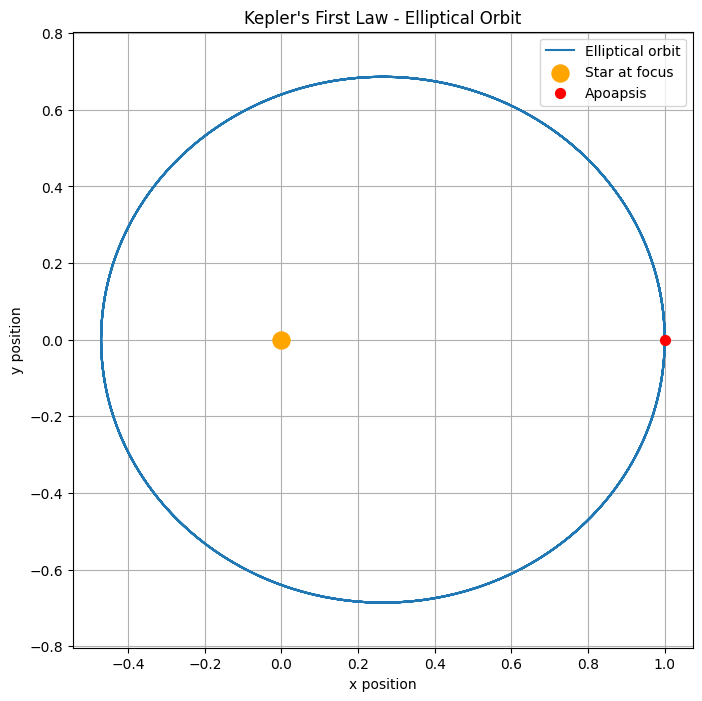

KEPLER'S FIRST LAW
-------------------------------------------------------
Minimum orbital radius: 0.470589
Maximum orbital radius: 1.000000
Measured semi-major axis: 0.735295
Theoretical semi-major axis: 0.735294
Orbital eccentricity: 0.359999


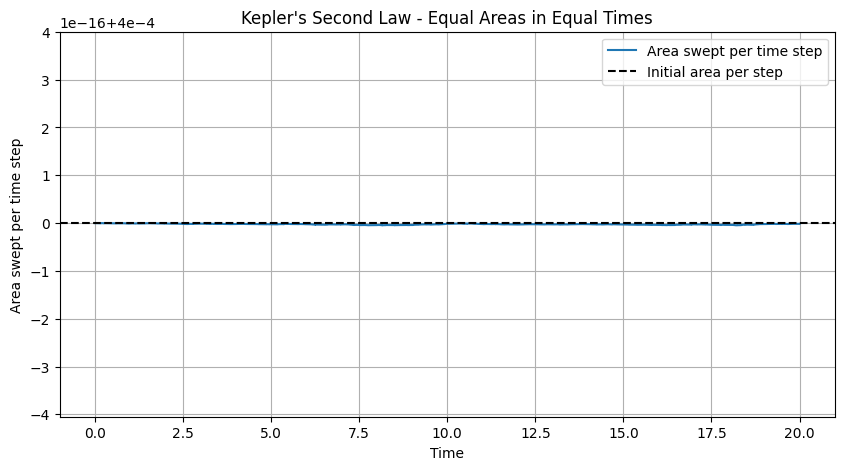


KEPLER'S SECOND LAW
-------------------------------------------------------
Initial area per step: 0.00040000
Mean area per step: 0.00040000
Maximum fractional area variation: 1.179070e-14

KEPLER'S THIRD LAW - ORBITAL MEASUREMENTS
---------------------------------------------------------------------------
    v0 |            a |            T |          a^3 |          T^2
---------------------------------------------------------------------------
  0.72 |     0.674947 |     3.484058 |     0.307474 |    12.138661
  0.80 |     0.735295 |     3.961615 |     0.397543 |    15.694396
  0.88 |     0.815927 |     4.630811 |     0.543193 |    21.444414
  0.96 |     0.927300 |     5.610612 |     0.797372 |    31.478966
---------------------------------------------------------------------------

KEPLER'S THIRD LAW - SLOPE COMPARISON
-------------------------------------------------------
Measured slope:    39.47845119
Theoretical slope: 39.47841760
Percent error:     0.000085%


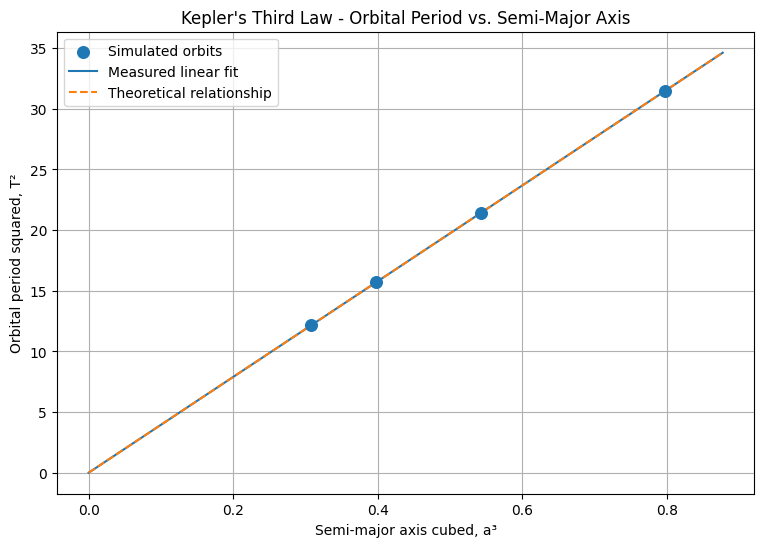

In [14]:

# PART C - VERIFICATION OF KEPLER'S THREE LAWS

# C1. FIRST LAW - ELLIPTICAL ORBITS

# Calculate distance from the star at each position
r_magnitudes = np.linalg.norm(rs, axis=1)

# Minimum and maximum orbital radii
r_min = np.min(r_magnitudes)
r_max = np.max(r_magnitudes)

# Calculate semi-major axis
semi_major_axis = (r_min + r_max) / 2

# Calculate orbital eccentricity
eccentricity = (r_max - r_min) / (r_max + r_min)

# Calculate theoretical semi-major axis from initial energy
specific_energy = energy(r0, v0, G, M, m) / m

a_theory = -G * M / (2 * specific_energy)

# C2. FIRST LAW - ORBITAL TRAJECTORY

plt.figure(figsize=(8, 8))

plt.plot(
    rs[:, 0],
    rs[:, 1],
    label="Elliptical orbit"
)

# Mark the central star
plt.scatter(
    0, 0,
    color="orange",
    s=150,
    label="Star at focus",
    zorder=5
)

# Mark the initial position
plt.scatter(
    r0[0],
    r0[1],
    color="red",
    s=50,
    label="Apoapsis",
    zorder=5
)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Kepler's First Law - Elliptical Orbit")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# Report orbital measurements
print("KEPLER'S FIRST LAW")
print("-" * 55)

print(f"Minimum orbital radius: {r_min:.6f}")
print(f"Maximum orbital radius: {r_max:.6f}")

print(f"Measured semi-major axis: {semi_major_axis:.6f}")
print(f"Theoretical semi-major axis: {a_theory:.6f}")

print(f"Orbital eccentricity: {eccentricity:.6f}")

# C3. SECOND LAW - EQUAL AREAS IN EQUAL TIMES

# Calculate the 2D cross product of position and velocity
cross_products = (
    rs[:, 0] * vs[:, 1]
    - rs[:, 1] * vs[:, 0]
)

# Calculate approximate area swept during each time step
areas = 0.5 * np.abs(cross_products) * dt

# Calculate fractional variation in area swept
area_error = np.abs(
    (areas - areas[0]) / areas[0]
)

# C4. SECOND LAW - AREA SWEPT VS. TIME

plt.figure(figsize=(10, 5))

plt.plot(
    times,
    areas,
    label="Area swept per time step"
)

# Initial area reference
plt.axhline(
    areas[0],
    color="black",
    linestyle="--",
    label="Initial area per step"
)

plt.xlabel("Time")
plt.ylabel("Area swept per time step")
plt.title("Kepler's Second Law - Equal Areas in Equal Times")

plt.grid(True)
plt.legend()
plt.show()

# Report area measurements
print("\nKEPLER'S SECOND LAW")
print("-" * 55)

print(f"Initial area per step: {areas[0]:.8f}")
print(f"Mean area per step: {np.mean(areas):.8f}")

print(
    f"Maximum fractional area variation: "
    f"{np.max(area_error):.6e}"
)

# C5. THIRD LAW - ORBITAL PERIOD FUNCTION

def measure_period(positions, velocities, times):
    """
    Measure the orbital period using the first return
    to the positive x-axis with upward velocity.

    Linear interpolation improves the period estimate.
    """

    for i in range(1, len(times)):

        y_previous = positions[i - 1, 1]
        y_current = positions[i, 1]

        # Detect crossing from negative y to positive y
        if y_previous < 0 <= y_current:

            # Require positive x position and upward motion
            if positions[i, 0] > 0 and velocities[i, 1] > 0:

                # Fraction of time step needed to reach y = 0
                fraction = (
                    -y_previous / (y_current - y_previous)
                )

                # Interpolated crossing time
                crossing_time = (
                    times[i - 1]
                    + fraction * (times[i] - times[i - 1])
                )

                return crossing_time - times[0]

    raise RuntimeError(
        "No complete orbit detected. "
        "Increase the simulation duration."
    )

# C6. THIRD LAW - SIMULATE FOUR DIFFERENT ORBITS

# Select four different initial tangential velocities
initial_speeds = [0.72, 0.80, 0.88, 0.96]

# Simulation parameters
dt_C = 0.001
n_steps_C = 15000

# Storage
semi_major_axes = []
periods = []

# Run each orbit using Velocity Verlet
for speed in initial_speeds:

    # Initial conditions use r = [1, 0] and v = [0, speed]
    r = np.array([1.0, 0.0])
    v = np.array([0.0, speed])
    a = accel(r)

    # Store initial position and velocity
    positions = [r.copy()]
    velocities = [v.copy()]

    # Simulate the orbit
    for _ in range(n_steps_C):

        r, v, a = verlet_step(r, v, a, dt_C, accel)

        positions.append(r.copy())
        velocities.append(v.copy())

    # Convert lists into NumPy arrays
    positions = np.array(positions)
    velocities = np.array(velocities)

    # Calculate distance from the star
    distances = np.linalg.norm(positions, axis=1)

    # Determine minimum and maximum orbital radii
    r_min_C = np.min(distances)
    r_max_C = np.max(distances)

    # Calculate semi-major axis
    a_C = (r_min_C + r_max_C) / 2

    # Generate time array
    times_C = np.arange(n_steps_C + 1) * dt_C

    # Measure orbital period
    T_C = measure_period(
        positions,
        velocities,
        times_C
    )

    # Store orbital measurements
    semi_major_axes.append(a_C)
    periods.append(T_C)

# Convert results into NumPy arrays
semi_major_axes = np.array(semi_major_axes)
periods = np.array(periods)

# C7. THIRD LAW - ORBITAL MEASUREMENT TABLE

# Calculate a cubed and T squared
a_cubed = semi_major_axes**3
T_squared = periods**2

print("\nKEPLER'S THIRD LAW - ORBITAL MEASUREMENTS")
print("-" * 75)

print(
    f"{'v0':>6} | "
    f"{'a':>12} | "
    f"{'T':>12} | "
    f"{'a^3':>12} | "
    f"{'T^2':>12}"
)

print("-" * 75)

for i in range(len(initial_speeds)):

    print(
        f"{initial_speeds[i]:6.2f} | "
        f"{semi_major_axes[i]:12.6f} | "
        f"{periods[i]:12.6f} | "
        f"{a_cubed[i]:12.6f} | "
        f"{T_squared[i]:12.6f}"
    )

print("-" * 75)

# C8. THIRD LAW - SLOPE COMPARISON

# Calculate the measured best-fit slope through the origin
measured_slope = (
    np.dot(a_cubed, T_squared)
    / np.dot(a_cubed, a_cubed)
)

# Calculate theoretical slope
theoretical_slope = 4 * np.pi**2 / (G * M)

# Calculate percent error
slope_error = (
    abs(measured_slope - theoretical_slope)
    / theoretical_slope
) * 100

print("\nKEPLER'S THIRD LAW - SLOPE COMPARISON")
print("-" * 55)

print(f"Measured slope:    {measured_slope:.8f}")
print(f"Theoretical slope: {theoretical_slope:.8f}")

print(f"Percent error:     {slope_error:.6f}%")


# C9. THIRD LAW - T^2 VS. a^3

# Generate coordinates for fitted lines
x_fit = np.linspace(
    0,
    1.1 * np.max(a_cubed),
    200
)

plt.figure(figsize=(9, 6))

# Plot numerical measurements
plt.scatter(
    a_cubed,
    T_squared,
    s=70,
    label="Simulated orbits",
    zorder=5
)

# Plot measured relationship
plt.plot(
    x_fit,
    measured_slope * x_fit,
    label="Measured linear fit"
)

# Plot theoretical relationship
plt.plot(
    x_fit,
    theoretical_slope * x_fit,
    linestyle="--",
    label="Theoretical relationship"
)

plt.xlabel("Semi-major axis cubed, a³")
plt.ylabel("Orbital period squared, T²")

plt.title("Kepler's Third Law - Orbital Period vs. Semi-Major Axis")

plt.grid(True)
plt.legend()
plt.show()

## Part C - Interpretation

Kepler's First Law:

The orbital simulation demonstrated how the planet follows a closed elliptical trajectory with the central star positioned at one focus. The minimum orbital radius was 0.470589, whereas the maximum orbital radius was 1.000000. Using the average of these values, the measured semi-major axis was 0.735295. This agrees closely with the theoretical value of 0.735294.

Furthermore, the orbital eccentricity was approximately 0.359999. This confirms that that the trajectory is elliptical rather than circular. This close agreement demonstrates that Velocity Verlet accurately reproduces the expected orbital geometry.

Kepler's Second Law:

The area swept during each equal time interval remained approximately constant at 0.00040000, throughout the duration of the simulation. The maximum fractional variation within the area swept per time step was 1.179070e-14, which indicates how the areal velocity was conserved within floating-point precision.

Though the planet moves faster near periapsis and slower near apoapsis, its change in distance from the star compensates for the change in tangential velocity. This allows equal areas to be swept during equal time intervals.

In all, the behaviors in relation to Kepler's Second Law, directly following the conservation of angular momentum. Given that gravity is a central force, it produces zero torque about the star. As a result, the angular momentum remained constant, and the planet was swept out to equal areas in equal times.

Kepler's Third Law

Four elliptical orbits were simulated using initial tangential velocities of 0.72, 0.80, 0.88, and 0.96. For each orbit, the orbital period and semi-major axis were measured and used to plot the squared orbital period against the cubed semi-major axis.

The resulting measurements followed the respective trend of a straight line through the origin. This demonstrates the expected relationship between orbital period and semi-major axis.

Moreover, the measured slope was 39.47845119, whereas the theoretical slope was 39.47841760. This results in a percent error was only 0.000085%, which indicates an extremely close agreement between the numerical simulation and Kepler's third law.

Numerical Error Analysis

The small difference between the measured and theoretical slopes are at the faults of numerical integration error, finite time-step resolution, and uncertainty in estimating the orbital periods and semi-major axes.

Though the use of linear interpolation helped improve the accuracy of the orbital period measurements, the semi-major axes were still estimated using the minimum and maximum radii recorded at discrete time steps. Unfortunately resulting in the actual orbital extrema to occur between recorded positions.

Additionally, Velocity Verlet still introduces small, bounded errors within the simulated trajectory. These errors affected both the measured orbital periods and the estimated semi-major axes.

Furthermore, the simulation uses a time step of 0.001, which should provide sufficient resolution to reproduce the relationship with an error of only 0.000085%. In this way, should we further reduce the time step and compare the resulting measurements, we would be capable of determining which sources of numerical error contributed most significantly.

Overall, the results demonstrate that Velocity Verlet successfully reproduces all three of Kepler's laws whilst maintaining the expected conservation properties of gravitational orbital motion!
